In [1]:
import pandas as pd

orders = pd.read_csv("/content/orders.csv")
order_products_prior = pd.read_csv("/content/order_products__prior.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [2]:
# ==============================
# 1. CUSTOMER-LEVEL AGGREGATION
# ==============================

# Total number of orders per customer
customer_orders = orders.groupby('user_id').agg(
    total_orders=('order_number', 'max'),
    avg_days_between_orders=('days_since_prior_order', 'mean'),
    avg_order_hour=('order_hour_of_day', 'mean'),
    order_variance=('days_since_prior_order', 'std')
).reset_index()

# Basket size per order
basket_size = order_products_prior.groupby('order_id').size().reset_index(name='basket_size')

# Merge basket size with orders
orders_basket = orders.merge(basket_size, on='order_id', how='left')

# Average basket size per customer
customer_basket = orders_basket.groupby('user_id').agg(
    avg_basket_size=('basket_size', 'mean')
).reset_index()

# Reorder rate per customer
customer_reorder = order_products_prior.groupby('order_id')['reordered'].mean().reset_index()
orders_reorder = orders.merge(customer_reorder, on='order_id', how='left')

customer_reorder_rate = orders_reorder.groupby('user_id').agg(
    reorder_rate=('reordered', 'mean')
).reset_index()

# Merge all features
customer_features = customer_orders.merge(customer_basket, on='user_id')
customer_features = customer_features.merge(customer_reorder_rate, on='user_id')

# Replace NaN from std calculation
customer_features['order_variance'] = customer_features['order_variance'].fillna(0)

customer_features.fillna(0, inplace=True)

print("Customer-level dataset shape:", customer_features.shape)
customer_features.head()

import numpy as np

customer_features['total_orders'] = np.log1p(customer_features['total_orders'])
customer_features['avg_basket_size'] = np.log1p(customer_features['avg_basket_size'])



Customer-level dataset shape: (206209, 7)


**Feature Scaling**

Feature scaling completed.
Explained variance: [0.38751871 0.17601242]


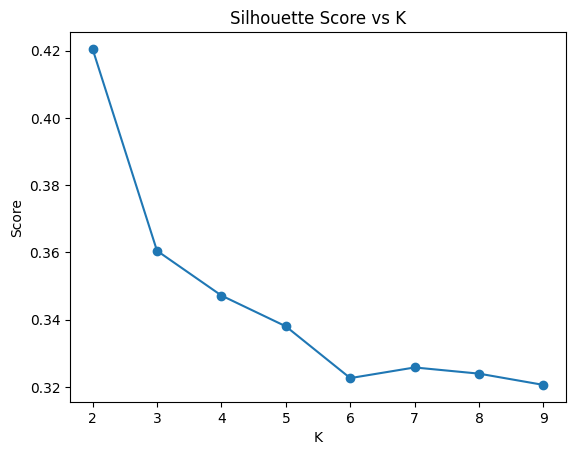

In [6]:
from sklearn.preprocessing import StandardScaler

features = customer_features.drop('user_id', axis=1)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print("Feature scaling completed.")

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

print("Explained variance:", pca.explained_variance_ratio_)


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(pca_features)
    score = silhouette_score(pca_features, labels, sample_size=10000, random_state=42)
    scores.append(score)

plt.plot(range(2,10), scores, marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()

**Elbow Method (Find Optimal K)**

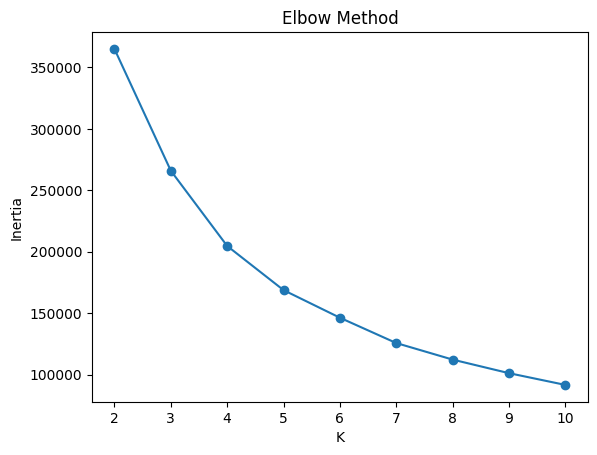

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans.fit(pca_features)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

**Apply K-Means (Example K=4)**

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_features)

customer_features['cluster'] = clusters

print("K-Means clustering completed.")
customer_features.head()

K-Means clustering completed.


,user_id,total_orders,avg_days_between_orders,avg_order_hour,order_variance,avg_basket_size,reorder_rate,cluster
0,1,2.484907,19.000000,10.090909,9.030811,1.931521,0.705833,3
1,2,2.772589,16.285714,10.600000,10.268912,2.703277,0.447961,3
2,3,2.639057,12.000000,16.307692,5.134553,2.120264,0.658817,2
3,4,1.945910,17.000000,12.500000,10.977249,1.526056,0.028571,3
4,5,1.791759,11.500000,15.000000,5.446712,2.327278,0.377778,1


**Evaluate Model (Silhouette Score)**

In [9]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_features, clusters)

print("Silhouette Score:", round(score, 4))

Silhouette Score: 0.1972


**Cluster Profiling**

In [10]:
cluster_profile = customer_features.groupby('cluster').mean()
cluster_profile

,user_id,total_orders,avg_days_between_orders,avg_order_hour,order_variance,avg_basket_size,reorder_rate
cluster,,,,,,,
0,103579.950612,1.820155,27.025311,13.634779,3.101450,2.116876,0.291744
1,103057.352631,2.235210,17.140152,15.083349,9.362932,2.472698,0.371288
2,102813.733243,3.370304,8.967228,13.331429,5.789577,2.328862,0.657872
3,103341.798101,2.232864,17.037017,12.073329,9.668329,1.937138,0.377236


**Visualization**

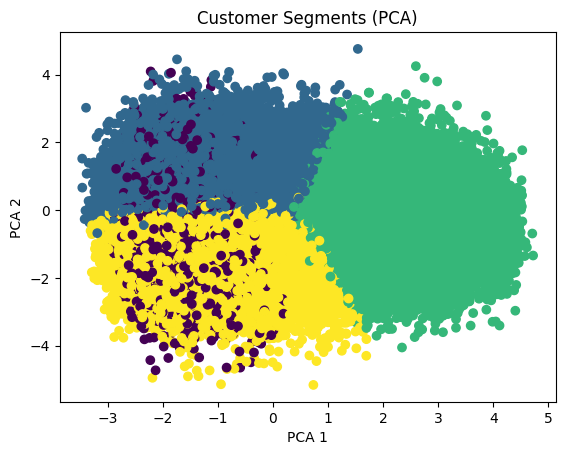

In [11]:
plt.scatter(pca_features[:,0], pca_features[:,1], c=clusters)
plt.title("Customer Segments (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

We used K-Means clustering to group customers based on how they shop. First, we took the raw transaction data and converted it into customer-level features like how often a customer orders, their average basket size, how frequently they reorder items, and how much time they take between orders.

After that, we slightly transformed some features to reduce skewness and then scaled all the data so that no single feature dominates the clustering. We also applied PCA to reduce the number of dimensions and make the data easier for the model to work with.

To decide how many clusters to use, we tried different values and used the Elbow Method and Silhouette Score to find the best one.

Finally, we ran K-Means to group similar customers together and analyzed each cluster to understand different types of shoppers, such as frequent buyers, occasional users, and bulk purchasers.